In [2]:

import os
import numpy as np
import pandas as pd
import nibabel as nib
from itertools import combinations
from scipy.ndimage import center_of_mass
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

In [3]:
root_dir='\\common_cross_species_atlas\\data\\' #<- set path here
# ---- Working directory ----
WORK_DIR = WORK_DIR = os.path.abspath(root_dir)
ATLAS_DIR = os.path.join(WORK_DIR, "atlas")
TRACER_DIR = os.path.join(WORK_DIR, "primate_tracer")
OUT_DIR = os.path.join(WORK_DIR, "homology_confidence")
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:


# ---- CHA label map (integer label -> region name) ----
LABEL_MAP = {
    1: "FRO_Precentral", 2: "FRO_Premotor", 3: "FRO_Prefrontal",
    4: "PAR", 5: "TEM_Superior", 6: "TEM_Inferior", 7: "TEM_Medial",
    8: "TEM_Hippocampus", 9: "TEM_Amygdala", 10: "OCC_Lateral",
    11: "OCC_Medial", 12: "INS_Anterior", 13: "INS_Posterior",
    14: "OLF_Anterior", 15: "OLF_Piriform", 16: "CIN_Anterior",
    17: "CIN_Posterior", 18: "BG_CaudoPutamen", 19: "BG_Accumbens",
    20: "BG_Pallidum", 21: "THL_Thalamus", 22: "THL_Hypothalamus",
}

REGION_ORDER = [
    "FRO_Precentral", "FRO_Premotor", "FRO_Prefrontal", "PAR",
    "TEM_Superior", "TEM_Inferior", "TEM_Medial",
    "TEM_Hippocampus", "TEM_Amygdala",
    "OCC_Lateral", "OCC_Medial", "INS_Anterior", "INS_Posterior",
    "OLF_Anterior", "OLF_Piriform", "CIN_Anterior", "CIN_Posterior",
    "BG_CaudoPutamen", "BG_Accumbens", "BG_Pallidum",
    "THL_Thalamus", "THL_Hypothalamus",
]

# Cortical regions with adequate marmoset tracer coverage
CORTICAL_TRACER = [
    "FRO_Precentral", "FRO_Premotor", "FRO_Prefrontal", "PAR",
    "TEM_Superior", "TEM_Inferior", "TEM_Medial",
    "OCC_Lateral", "OCC_Medial", "CIN_Anterior", "CIN_Posterior",
]

EXCLUDED_TRACER = ["OLF_Anterior", "OLF_Piriform", "INS_Anterior", "INS_Posterior"]


In [5]:

# ==================================================================
# CRITERION 1: Nomenclature Directness
# ==================================================================
# Score per species: 3=same term, 2=recognized equivalent, 1=functional analog
NOMENCLATURE = {
    "FRO_Precentral":   [2, 2, 3, 3],
    "FRO_Premotor":     [2, 2, 3, 3],
    "FRO_Prefrontal":   [1, 2, 3, 3],
    "PAR":              [2, 3, 3, 3],
    "TEM_Superior":     [1, 2, 3, 3],
    "TEM_Inferior":     [1, 2, 3, 3],
    "TEM_Medial":       [3, 3, 3, 3],
    "TEM_Hippocampus":  [3, 3, 3, 3],
    "TEM_Amygdala":     [3, 3, 3, 3],
    "OCC_Lateral":      [2, 2, 3, 3],
    "OCC_Medial":       [2, 2, 3, 3],
    "INS_Anterior":     [2, 2, 3, 3],
    "INS_Posterior":    [2, 2, 3, 3],
    "OLF_Anterior":     [3, 2, 2, 3],
    "OLF_Piriform":     [3, 3, 3, 3],
    "CIN_Anterior":     [2, 2, 3, 3],
    "CIN_Posterior":    [2, 2, 3, 3],
    "BG_CaudoPutamen":  [3, 3, 3, 3],
    "BG_Accumbens":     [3, 3, 3, 3],
    "BG_Pallidum":      [3, 3, 3, 3],
    "THL_Thalamus":     [3, 3, 3, 3],
    "THL_Hypothalamus": [3, 3, 3, 3],
}

df_nom = pd.DataFrame(NOMENCLATURE, index=["mouse", "marmoset", "rhesus", "human"]).T
df_nom["mean"] = df_nom.mean(axis=1)
df_nom["normalized"] = df_nom["mean"] / 3.0


In [7]:

# ==================================================================
# CRITERION 2: Geometric Consistency
# ==================================================================

def load_centroids(atlas_path, label_map):
    """Compute world-coordinate centroids for each CHA region."""
    img = nib.load(atlas_path)
    data = img.get_fdata()
    affine = img.affine
    centroids = {}
    for label_int, name in label_map.items():
        mask = data == label_int
        if mask.sum() == 0:
            continue
        com_vox = center_of_mass(mask.astype(float))
        com_world = affine @ np.array([*com_vox, 1])
        centroids[name] = com_world[:3]
    return centroids


def compute_geometric_consistency(centroids_per_species):
    """
    Compute mean resultant length R for each region pair across species.
    R = ||mean of unit direction vectors||; R=1 identical, R=0 scattered.
    """
    species_list = list(centroids_per_species.keys())
    common = sorted(set.intersection(*(set(c.keys()) for c in centroids_per_species.values())))
    pairs = list(combinations(common, 2))

    pair_results = []
    for regA, regB in pairs:
        uvecs = []
        for sp in species_list:
            vec = np.array(centroids_per_species[sp][regB]) - np.array(centroids_per_species[sp][regA])
            norm = np.linalg.norm(vec)
            if norm > 0:
                uvecs.append(vec / norm)
        R = np.linalg.norm(np.mean(uvecs, axis=0)) if len(uvecs) >= 2 else np.nan
        row = {"regionA": regA, "regionB": regB, "mean_resultant_R": R, "n_species": len(uvecs)}
        for sp, uv in zip(species_list, uvecs):
            row[f"{sp}_x"], row[f"{sp}_y"], row[f"{sp}_z"] = uv
        pair_results.append(row)

    df_pairs = pd.DataFrame(pair_results).sort_values("mean_resultant_R")

    region_scores = {}
    for r in common:
        mask = (df_pairs["regionA"] == r) | (df_pairs["regionB"] == r)
        region_scores[r] = df_pairs.loc[mask, "mean_resultant_R"].mean()

    df_regions = pd.Series(region_scores, name="geometric_consistency").sort_values(ascending=False)
    return df_pairs, df_regions


atlas_paths = {
    "mouse":    os.path.join(ATLAS_DIR, "cha_mouse.nii.gz"),
    "marmoset": os.path.join(ATLAS_DIR, "cha_marmoset_moused.nii.gz"),
    "rhesus":   os.path.join(ATLAS_DIR, "cha_rhesus_moused.nii.gz"),
    "human":    os.path.join(ATLAS_DIR, "cha_human_moused.nii.gz"),
}

centroids_per_species = {sp: load_centroids(p, LABEL_MAP) for sp, p in atlas_paths.items()}
df_geo_pairs, df_geo_regions = compute_geometric_consistency(centroids_per_species)

df_geo_pairs.to_csv(os.path.join(OUT_DIR, "geometric_consistency_pairs.csv"), index=False)
df_geo_regions.to_csv(os.path.join(OUT_DIR, "geometric_consistency_regions.csv"))


In [8]:

# ==================================================================
# CRITERION 3: Connectivity Correspondence
# ==================================================================

df_tracer = pd.read_csv(os.path.join(TRACER_DIR, "weighted_agreement_pairs.csv"))

region_agree = {}
for r in CORTICAL_TRACER:
    sub = df_tracer[(df_tracer["source"] == r) | (df_tracer["target"] == r)]
    if len(sub) > 0:
        region_agree[r] = sub["agreement"].mean()

In [9]:

# ==================================================================
# COMBINED INDEX
# ==================================================================

combined = pd.DataFrame(index=REGION_ORDER)
combined["nomenclature"] = df_nom["normalized"]

combined["geometric"] = np.nan
for r in REGION_ORDER:
    if r in df_geo_regions.index:
        combined.loc[r, "geometric"] = df_geo_regions[r]

combined["connectivity"] = np.nan
for r in REGION_ORDER:
    if r in region_agree:
        combined.loc[r, "connectivity"] = region_agree[r]

criteria = ["nomenclature", "geometric", "connectivity"]
combined["n_criteria"] = combined[criteria].notna().sum(axis=1)
combined["confidence"] = combined[criteria].mean(axis=1, skipna=True)

combined.to_csv(os.path.join(OUT_DIR, "homology_confidence_index.csv"))
print("Homology confidence index saved.")
print(combined[["nomenclature", "geometric", "connectivity", "confidence"]].to_string())


Homology confidence index saved.
                  nomenclature  geometric  connectivity  confidence
FRO_Precentral        0.833333   0.933168      0.898515    0.888339
FRO_Premotor          0.833333   0.960430      0.864686    0.886150
FRO_Prefrontal        0.750000   0.978565      0.793729    0.840765
PAR                   0.916667   0.915238      0.805941    0.879282
TEM_Superior          0.750000   0.905043      0.812981    0.822675
TEM_Inferior          0.750000   0.931100      0.771658    0.817586
TEM_Medial            1.000000   0.950230      0.732673    0.894301
TEM_Hippocampus       1.000000   0.920477           NaN    0.960238
TEM_Amygdala          1.000000   0.969272           NaN    0.984636
OCC_Lateral           0.833333   0.958769      0.764982    0.852361
OCC_Medial            0.833333   0.945118      0.786634    0.855028
INS_Anterior          0.833333   0.922721           NaN    0.878027
INS_Posterior         0.833333   0.878189           NaN    0.855761
OLF_Anterior   

Figure 7 saved.


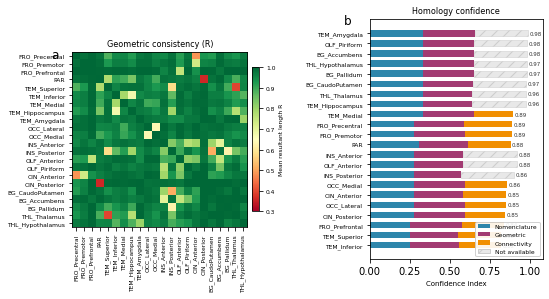

In [10]:

# ==================================================================
# FIGURE 7
# ==================================================================

mm_to_inch = 1 / 25.4
regions = [r for r in REGION_ORDER if r in combined.index]
n = len(regions)

# Panel A: build symmetric R matrix
R_matrix = pd.DataFrame(np.nan, index=regions, columns=regions)
for _, row in df_geo_pairs.iterrows():
    rA, rB, R = row["regionA"], row["regionB"], row["mean_resultant_R"]
    if rA in regions and rB in regions:
        R_matrix.loc[rA, rB] = R
        R_matrix.loc[rB, rA] = R
np.fill_diagonal(R_matrix.values, 1.0)
R_matrix = R_matrix.loc[regions, regions]

# Panel B: prepare bar data
df_bar = combined.loc[regions].sort_values("confidence", ascending=True)
regions_bar = df_bar.index.tolist()
n_bar = len(regions_bar)
y_pos = np.arange(n_bar)
max_per = 1.0 / 3.0

nom_vals = df_bar["nomenclature"].fillna(0).values * max_per
geo_vals = df_bar["geometric"].fillna(0).values * max_per
con_vals = df_bar["connectivity"].fillna(0).values * max_per
geo_missing = df_bar["geometric"].isna().values
con_missing = df_bar["connectivity"].isna().values

C_NOM, C_GEO, C_CON, C_MISS = "#2E86AB", "#A23B72", "#F18F01", "#E8E8E8"

# Plot
fig = plt.figure(figsize=(200 * mm_to_inch, 110 * mm_to_inch))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.1, 0.9],
                       wspace=0.45, left=0.12, right=0.95, top=0.92, bottom=0.15)

ax_heat = fig.add_subplot(gs[0, 0])
im = ax_heat.imshow(R_matrix.values, cmap="RdYlGn", vmin=0.3, vmax=1.0, interpolation="nearest")
ax_heat.set_xticks(range(n)); ax_heat.set_yticks(range(n))
ax_heat.set_xticklabels(regions, rotation=90, fontsize=6)
ax_heat.set_yticklabels(regions, fontsize=6)
ax_heat.set_title("Geometric consistency (R)", fontsize=8, fontweight="normal")
cbar = plt.colorbar(im, ax=ax_heat, shrink=0.6, pad=0.02)
cbar.set_label("Mean resultant length R", fontsize=6)
cbar.ax.tick_params(labelsize=6)

ax_bar = fig.add_subplot(gs[0, 1])
ax_bar.barh(y_pos, nom_vals, height=0.65, color=C_NOM)
ax_bar.barh(y_pos, geo_vals, left=nom_vals, height=0.65, color=C_GEO)
ax_bar.barh(y_pos, con_vals, left=nom_vals + geo_vals, height=0.65, color=C_CON)

for i in range(n_bar):
    if geo_missing[i]:
        ax_bar.barh(y_pos[i], max_per, left=nom_vals[i], height=0.6,
                     color=C_MISS, edgecolor="#CCCCCC", hatch="//", linewidth=0.5)
    if con_missing[i]:
        left = nom_vals[i] + (geo_vals[i] if not geo_missing[i] else max_per)
        ax_bar.barh(y_pos[i], max_per, left=left, height=0.6,
                     color=C_MISS, edgecolor="#CCCCCC", hatch="//", linewidth=0.5)

ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(regions_bar, fontsize=6)
ax_bar.set_xlim(0, 1.08)
ax_bar.set_xlabel("Confidence index", fontsize=7)
ax_bar.set_title("Homology confidence", fontsize=8, fontweight="normal")

for i, r in enumerate(regions_bar):
    total = df_bar.loc[r, "confidence"]
    if not np.isnan(total):
        bar_end = nom_vals[i] + geo_vals[i] + con_vals[i]
        if con_missing[i]:
            bar_end = nom_vals[i] + geo_vals[i] + max_per
        if geo_missing[i]:
            bar_end = nom_vals[i] + 2 * max_per
        ax_bar.text(min(bar_end + 0.01, 1.02), y_pos[i],
                    f"{total:.2f}", va="center", fontsize=5.5, color="#333333")

ax_bar.legend(handles=[
    mpatches.Patch(facecolor=C_NOM, label="Nomenclature"),
    mpatches.Patch(facecolor=C_GEO, label="Geometric"),
    mpatches.Patch(facecolor=C_CON, label="Connectivity"),
    mpatches.Patch(facecolor=C_MISS, edgecolor="#CCCCCC", hatch="//", label="Not available"),
], loc="lower right", fontsize=6, framealpha=0.9)

ax_heat.text(-0.12, 1.02, "a", transform=ax_heat.transAxes, fontsize=12, fontweight="normal", va="top")
ax_bar.text(-0.15, 1.02, "b", transform=ax_bar.transAxes, fontsize=12, fontweight="normal", va="top")

plt.savefig(os.path.join(OUT_DIR, "fig7_confidence.svg"), bbox_inches="tight")
print("Figure 7 saved.")